In [1]:
import numpy as np
import pandas as pd
import os, os.path,sys
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import scipy
import plotly.express as px
import plotly.graph_objects as go


In [2]:
ROOT_DIR = ''
# ROOT_DIR = ''
ROOT_DIR ='/home/sergi_alcala/sergi_data/AZTEC_extension/'
print(f'Root dir: {ROOT_DIR}')

Root dir: /home/sergi_alcala/sergi_data/AZTEC_extension/


In [3]:
def load_real_data(city):
    ''' Load the real data for the city.'''

    bordeaux = pd.read_csv(os.path.join(ROOT_DIR,f'./citys/{city}.csv'))
    #bordeaux = pd.read_csv(f'/home/sergi_alcala/AZTEC_extension/citys/{city}.csv')

    bordeaux.drop('date_time', axis=1, inplace=True)
    bordeaux = bordeaux.reindex(sorted(bordeaux.columns), axis=1)
    bordeaux = bordeaux.to_numpy()
    return bordeaux

In [4]:
def fun_test_index_start(city,delay):
    bordeaux= load_real_data(city)
    test_index_start = round(len(bordeaux)*0.8) + delay
    return test_index_start


In [5]:
## Normalize df , each column is normalized independently by its max value
def normalize_df(df):
    max_values = df.max(axis=0)
    df = df / max_values
    return df

## Return Max values of each column
def max_values_df(df):
    max_values = df.max(axis=0)
    return max_values

In [6]:
# Load Deepcog's forecast

def load_deepcog_forecast(city,alpha,delay,run):
    ''' Load the Deepcog's forecast for the city.'''
    np_load_len=np.load('/home/sergi_alcala/sergi_data/CLEAN_AZTEC_Extension/Benchmark/exp_smooth/Paris_Exp_Smooth_Forecast.npy')
    infocom_19 = np.zeros((np_load_len.shape[0], np_load_len.shape[1],  run))
    #infocom_19 = np.zeros((3577, len(services),  run))
   

    for seed in range(run):
        
            for ser in range(np_load_len.shape[1]):
            
                np_load=np.load('/home/sergi_alcala/sergi_data/CLEAN_AZTEC_Extension/Benchmark/exp_smooth/Paris_Exp_Smooth_Forecast.npy')
                infocom_19[:, ser, seed] = np_load[:, ser]
    return infocom_19
                
             

In [7]:
def load_scalers(city,delay):
    bench_scaler = pickle.load(open(f'/home/sergi_alcala/sergi_data/AZTEC_extension/{results_fpath}/{city}/INFOCOM17_benchmark_delay_{delay}_block_1_minmaxscaler.pkl', 'rb'))
    return bench_scaler

In [8]:
def denormalize_normalize(infocom_19,Output_df,run):
    normalizer_value= 10e9
    infocom_19_denorm = np.zeros(infocom_19.shape)
    for i in range(run):
        infocom_19_denorm[:,:,i] =infocom_19[:,:,i]

  
    return infocom_19_denorm,Output_df
    

In [9]:
def fun_total_cost(Output_df_denorm,infocom_19_denorm,alpha,max_concatenated,phi,services,run,eta):
# def fun_total_cost(Output_df_norm,infocom_19_norm,city_df,alpha,num_services,phi,delta_demand):
    gamma = 2
    
    Output_df_denorm = np.array(Output_df_denorm)
   
    ### OVERPROVISIONING ###
    cost_overprovisioning_infocom = np.zeros(run)

    test_length=min(len(Output_df_denorm),len(infocom_19_denorm))

    cost_normalization_factor = (Output_df_denorm[:test_length].max(axis=0)
                                - Output_df_denorm[:test_length]).sum() * gamma

    for seed in range(run):
        cost_overprovisioning_infocom[seed] = (infocom_19_denorm[:test_length, :, seed] 
                                                - Output_df_denorm[:test_length]).clip(min=0).sum(axis=0).sum()
                                                
    cost_overprovisioning_infocom = cost_overprovisioning_infocom.mean(axis=-1) * gamma / cost_normalization_factor

    ### SLA ###
    slas_infocom_19 = np.zeros((len(services), run))


    for app in range(len(services)):
        for seed in range(run):
            slas_infocom_19[ app, seed] = np.where((infocom_19_denorm[:test_length, app, seed] 
                                                    - Output_df_denorm[:test_length, app]) < 0)[0].shape[0]
            
    cost_slas_infocom_19 = (slas_infocom_19.mean(axis=-1)*max_concatenated).sum()*alpha*gamma/cost_normalization_factor

    ### INSTANTIATION ###

    delta_demand_infocom_19 = np.zeros((infocom_19_denorm.shape[0], len(services), run))

    # for seed in range(run):
    #     for app in range(len(services)):
    #         delta_demand_infocom_19[:, app, seed] = (infocom_19_denorm[:, app,  seed] 
    #                                         - np.roll(infocom_19_denorm[:, app,  seed], 1))
    #         delta_demand_infocom_19[0, app,seed] = infocom_19_denorm[0, app, seed]

    
    for seed in range(run):
        for app in range(len(services)):
            delta_demand_infocom_19[:, app, seed] = (infocom_19_denorm[:, app,  seed] 
                                            - np.roll(infocom_19_denorm[:, app,  seed], 1,axis=0))
            delta_demand_infocom_19[0, app,seed] = infocom_19_denorm[0, app, seed]

    

    
    
    

    cost_instantiation_infocom19_prel = np.zeros((len(services), run))


    for app in range(len(services)):
        for seed in range(run):
            for time in range(test_length):
                if  delta_demand_infocom_19[time, app, seed] > 0:
                    cost_instantiation_infocom19_prel[app, seed] += np.min((Output_df_denorm[:test_length][time, app],
                                                                            infocom_19_denorm[time, app, seed]))

    #for i, element in enumerate(eta):
    
    cost_instantiation_infocom19= (cost_instantiation_infocom19_prel.mean(axis=-1)*
                                            eta).sum()/ cost_normalization_factor
        
    # for i in range(len(phi)):
    #     cost_instantiation_infocom19[i] = (cost_instantiation_infocom19_prel.mean(axis=-1)*
    #                                         max_concatenated*eta).sum()/ cost_normalization_factor
    
    ### RECONFIGURATION ###
    
    cost_reconfiguration_infocom_19_prel = np.zeros((len(services), run))
    
    for app in range(len(services)):
        for seed in range(run):
            index = np.where(delta_demand_infocom_19[:, app,  seed] != 0)[0]
            cost_reconfiguration_infocom_19_prel[ app, seed] = (np.min((Output_df_denorm[:test_length][index, app], 
                                                                infocom_19_denorm[index, app,  seed]),
                                                                    axis=0).sum(axis=0))
            
    cost_reconfiguration= cost_reconfiguration_infocom_19_prel.mean(axis=-1).sum()*phi/cost_normalization_factor
    
    total_cost = cost_overprovisioning_infocom + cost_slas_infocom_19 + cost_instantiation_infocom19 + cost_reconfiguration

    return total_cost,cost_overprovisioning_infocom,cost_slas_infocom_19,cost_instantiation_infocom19,cost_reconfiguration,delta_demand_infocom_19 ,index,cost_reconfiguration_infocom_19_prel


In [10]:
def cost_deepcog_analysis(city,alpha,delay,run,phi,services,eta,save_raw_data=False):

    city_df = pd.DataFrame(load_real_data(city))
    test_index_start = fun_test_index_start(city,delay)
    Output_df = city_df[test_index_start:]
    infocom_19 = load_deepcog_forecast(city,alpha,delay,run)
    # bench_scaler=load_scalers(city,delay)
    infocom_19_norm,Output_df_norm=denormalize_normalize(infocom_19,Output_df,run)

    # Output_df_norm.reset_index(drop=True, inplace=True)
    # Output_df_norm=Output_df_norm.to_numpy()
    max_concatenated = city_df.max(axis=0)
  
    


    total_cost,cost_overprovisioning_infocom,cost_slas_infocom_19,cost_instantiation_infocom19,cost_reconfiguration,delta_demand_infocom_19,index,cost_reconfiguration_infocom_19_prel= fun_total_cost(Output_df,infocom_19,alpha,max_concatenated,phi,services,run,eta)
    if save_raw_data:
        if not os.path.exists(f'/home/sergi_alcala/sergi_data/AZTEC_extension/{results_fpath}/{city}/raw_data_{results_fpath}'):
            os.makedirs(f'/home/sergi_alcala/sergi_data/AZTEC_extension/{results_fpath}/{city}/raw_data_{results_fpath}')

        np.save(f'/home/sergi_alcala/sergi_data/AZTEC_extension/{results_fpath}/{city}/raw_data_{results_fpath}/Output_df_norm.npy', Output_df_norm)
        np.save(f'/home/sergi_alcala/sergi_data/AZTEC_extension/{results_fpath}/{city}/raw_data_{results_fpath}/infocom_17_norm.npy', infocom_19_norm)
        np.save(f'/home/sergi_alcala/sergi_data/AZTEC_extension/{results_fpath}/{city}/raw_data_{results_fpath}/cost_overprovisioning_infocom.npy', cost_overprovisioning_infocom)
        np.save(f'/home/sergi_alcala/sergi_data/AZTEC_extension/{results_fpath}/{city}/raw_data_{results_fpath}/cost_slas_infocom_17.npy', cost_slas_infocom_19)
        np.save(f'/home/sergi_alcala/sergi_data/AZTEC_extension/{results_fpath}/{city}/raw_data_{results_fpath}/cost_instantiation_infocom17.npy', cost_instantiation_infocom19)
        np.save(f'/home/sergi_alcala/sergi_data/AZTEC_extension/{results_fpath}/{city}/raw_data_{results_fpath}/cost_reconfiguration.npy', cost_reconfiguration)
        

    
    return total_cost,cost_overprovisioning_infocom,cost_slas_infocom_19,cost_instantiation_infocom19,cost_reconfiguration,delta_demand_infocom_19,index,cost_reconfiguration_infocom_19_prel


In [11]:
city='Paris'
delay=1
# alphas=[2,3,5]
alphas = [2]
alpha=0.7
phis=[0.1,0.5,1,10]
# phi=0.1

run=10
gamma=2
services = ['youtube', 'snapchat', 'facebook', 'itunes', 'instagram']

In [12]:
cities=['Paris']
# ALPHAS=[2,3,5]
ALPHAS = [2,3,5]
PHIS=[0.1,0.5,1,10]
eta=2
delay=0
run=10
services = ['Deezer',	'Twitter',	'Netflix',	'DailyMotion',	'Google']
gamma=2

total_cost_list=[]
cost_overprovisioning_infocom_list=[]
cost_slas_infocom_19_list=[]
cost_instantiation_infocom19_list=[]
cost_reconfiguration_list=[]
sla_perc_list_index_list=[]

results_fpath = 'EXP_Smooth_results'
save_raw_data =False
for city in cities:
    for phi in PHIS:
        for alpha in ALPHAS:
        
            total_cost,cost_overprovisioning_infocom,cost_slas_infocom_19,cost_instantiation_infocom19,cost_reconfiguration,delta_demand_infocom_19,index,cost_reconfiguration_infocom_19_prel=cost_deepcog_analysis(city,alpha,delay,run,phi,services,eta)
            sla_perc_list_index=f'{city}_phi_{phi}_alpha_{alpha}_delay_{delay}'
            sla_perc_list_index_list.append(sla_perc_list_index)
            total_cost_list.append(total_cost)
            cost_overprovisioning_infocom_list.append(cost_overprovisioning_infocom)
            cost_slas_infocom_19_list.append(cost_slas_infocom_19)
            cost_instantiation_infocom19_list.append(cost_instantiation_infocom19)
            cost_reconfiguration_list.append(cost_reconfiguration)


            city_df = pd.DataFrame(load_real_data(city))
            test_index_start = fun_test_index_start(city,delay)
            Output_df = city_df[test_index_start:]
            infocom_19 = load_deepcog_forecast(city,alpha,delay,run)
            # bench_scaler=load_scalers(city,delay)
            infocom_19_norm,Output_df_norm=denormalize_normalize(infocom_19,Output_df,run)

            # Output_df_norm.reset_index(drop=True, inplace=True)
            # Output_df_norm=Output_df_norm.to_numpy()
            max_concatenated = city_df.max(axis=0)
            

In [ ]:
x.shape

(3582, 5)

In [18]:
cost_df=pd.DataFrame({'total_cost':total_cost_list,'cost_overprovisioning_Exp_Smooth':cost_overprovisioning_infocom_list,'cost_slas_Exp_Smooth':cost_slas_infocom_19_list,'cost_instantiation_Exp_Smooth':cost_instantiation_infocom19_list,'cost_reconfiguration':cost_reconfiguration_list},index=sla_perc_list_index_list)

In [19]:
cost_df

,total_cost,cost_overprovisioning_Exp_Smooth,cost_slas_Exp_Smooth,cost_instantiation_Exp_Smooth,cost_reconfiguration
Paris_phi_0.1_alpha_2_delay_0,2.270335,0.204413,1.848285,0.199155,0.018482
Paris_phi_0.1_alpha_3_delay_0,3.194478,0.204413,2.772428,0.199155,0.018482
Paris_phi_0.1_alpha_5_delay_0,5.042763,0.204413,4.620713,0.199155,0.018482
Paris_phi_0.5_alpha_2_delay_0,2.344263,0.204413,1.848285,0.199155,0.092409
Paris_phi_0.5_alpha_3_delay_0,3.268405,0.204413,2.772428,0.199155,0.092409
Paris_phi_0.5_alpha_5_delay_0,5.116690,0.204413,4.620713,0.199155,0.092409
Paris_phi_1_alpha_2_delay_0,2.436672,0.204413,1.848285,0.199155,0.184819
Paris_phi_1_alpha_3_delay_0,3.360815,0.204413,2.772428,0.199155,0.184819
Paris_phi_1_alpha_5_delay_0,5.209100,0.204413,4.620713,0.199155,0.184819
Paris_phi_10_alpha_2_delay_0,4.100041,0.204413,1.848285,0.199155,1.848187


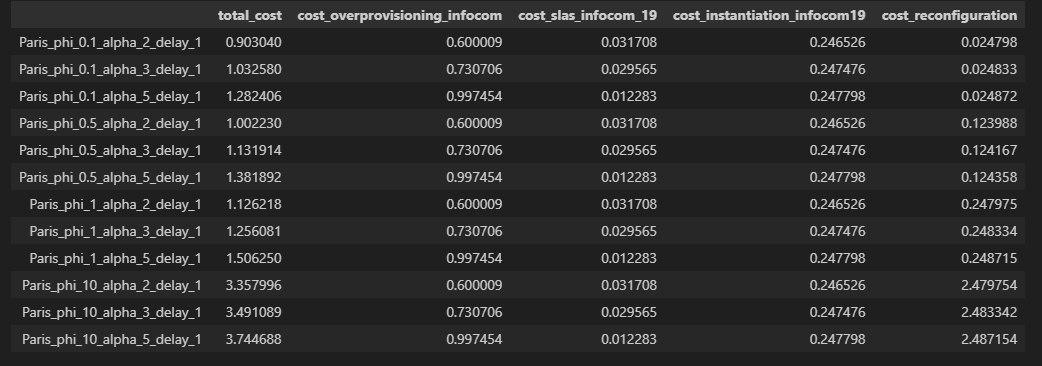

In [77]:
cost_df.to_csv(f'/home/sergi_alcala/sergi_data/CLEAN_AZTEC_Extension/Benchmark/exp_smooth/Costs_Exponential_Smooth.csv')

In [15]:
total_costs

Paris_phi_0.1_alpha_2_delay_0    2.270335
Paris_phi_0.1_alpha_3_delay_0    3.194478
Paris_phi_0.1_alpha_5_delay_0    5.042763
Paris_phi_0.5_alpha_2_delay_0    2.344263
Paris_phi_0.5_alpha_3_delay_0    3.268405
Paris_phi_0.5_alpha_5_delay_0    5.116690
Paris_phi_1_alpha_2_delay_0      2.436672
Paris_phi_1_alpha_3_delay_0      3.360815
Paris_phi_1_alpha_5_delay_0      5.209100
Paris_phi_10_alpha_2_delay_0     4.100041
Paris_phi_10_alpha_3_delay_0     5.024183
Paris_phi_10_alpha_5_delay_0     6.872468
Name: total_cost, dtype: float64

In [16]:
cost_df

,total_cost,cost_overprovisioning_infocom,cost_slas_infocom_17,cost_instantiation_infocom17,cost_reconfiguration
Paris_phi_0.1_alpha_2_delay_0,2.270335,0.204413,1.848285,0.199155,0.018482
Paris_phi_0.1_alpha_3_delay_0,3.194478,0.204413,2.772428,0.199155,0.018482
Paris_phi_0.1_alpha_5_delay_0,5.042763,0.204413,4.620713,0.199155,0.018482
Paris_phi_0.5_alpha_2_delay_0,2.344263,0.204413,1.848285,0.199155,0.092409
Paris_phi_0.5_alpha_3_delay_0,3.268405,0.204413,2.772428,0.199155,0.092409
Paris_phi_0.5_alpha_5_delay_0,5.116690,0.204413,4.620713,0.199155,0.092409
Paris_phi_1_alpha_2_delay_0,2.436672,0.204413,1.848285,0.199155,0.184819
Paris_phi_1_alpha_3_delay_0,3.360815,0.204413,2.772428,0.199155,0.184819
Paris_phi_1_alpha_5_delay_0,5.209100,0.204413,4.620713,0.199155,0.184819
Paris_phi_10_alpha_2_delay_0,4.100041,0.204413,1.848285,0.199155,1.848187


In [14]:
total_costs = cost_df.total_cost

In [66]:
total_costs.values

array([2.27033549, 2.34426297, 2.43667233, 4.10004072])

In [17]:
cost_df.to_csv(f'FINAL_RESULTS_PARIS/Costs_{city}_delay_{delay}_phi_{phi}_INFOCOM17.csv')

In [67]:
cost_df ### Cost infocom17

,total_cost,cost_overprovisioning_infocom,cost_slas_infocom_17,cost_instantiation_infocom17,cost_reconfiguration
Paris_phi_0.1_alpha_2_delay_0,2.270335,0.204413,1.848285,0.199155,0.018482
Paris_phi_0.5_alpha_2_delay_0,2.344263,0.204413,1.848285,0.199155,0.092409
Paris_phi_1_alpha_2_delay_0,2.436672,0.204413,1.848285,0.199155,0.184819
Paris_phi_10_alpha_2_delay_0,4.100041,0.204413,1.848285,0.199155,1.848187


In [68]:
cost_df ### Cost infocom17

,total_cost,cost_overprovisioning_infocom,cost_slas_infocom_17,cost_instantiation_infocom17,cost_reconfiguration
Paris_phi_0.1_alpha_2_delay_0,2.270335,0.204413,1.848285,0.199155,0.018482
Paris_phi_0.5_alpha_2_delay_0,2.344263,0.204413,1.848285,0.199155,0.092409
Paris_phi_1_alpha_2_delay_0,2.436672,0.204413,1.848285,0.199155,0.184819
Paris_phi_10_alpha_2_delay_0,4.100041,0.204413,1.848285,0.199155,1.848187


why many sla, time series aligned?
% SLA
shared capacity well allocated? bad opt? or bad shared cap forecast

SLA viol index, shared total cap check

total, needed, served

block 4




In [ ]:
cost_overprov= (0.6,0.73,0.99)
cost_sla=(0.03,0.02,0.01)
cost_instantiation=(0.246,0.2474,0.24778)
cost_reconf=(0.024798,0.024798,0.024798)

In [18]:
cost_overprovisioning = np.array([0.18780211, 0.19197072, 0.19877882]) # for different alpha

cost_slas = np.array([0.10121839, 0.07697521, 0.08069174]) # for different alpha

cost_instantiation = np.array([0.35578701, 0.37395105, 0.38364393]) # for different alpha and for eta = 2

cost_reconfiguration = np.array([[0.03507828, 0.03685982, 0.03776066],
       						  [0.3507828 , 0.36859822, 0.37760659],
       						  [3.50782801, 3.68598217, 3.7760659 ]])   # row = phis; column = alphas

In [23]:
total_cost_no_inst = cost_overprovisioning + cost_slas + cost_instantiation 

In [26]:
total_cost_no_inst

array([0.64480751, 0.64289698, 0.66311449])

In [28]:
cost_reconfiguration

array([[0.03507828, 0.03685982, 0.03776066],
       [0.3507828 , 0.36859822, 0.37760659],
       [3.50782801, 3.68598217, 3.7760659 ]])

In [24]:
total_cost = cost_overprovisioning + cost_slas + cost_instantiation + cost_reconfiguration

In [25]:
total_cost

array([[0.67988579, 0.6797568 , 0.70087515],
       [0.99559031, 1.0114952 , 1.04072108],
       [4.15263552, 4.32887915, 4.43918039]])